# MAREX Project

# Importation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Lecture of the Excel File

In [2]:
file_path = 'prices 002.xlsx'

In [3]:
data=pd.read_excel(file_path) # Import the data

# Analyze of the data

In [4]:
data.shape # See the number of rows and columns

(3314, 86)

In [5]:
data.head() # Visualized the first 5 rows to see how look the data

,date,y,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,...,x_75,x_76,x_77,x_78,x_79,x_80,x_81,x_82,x_83,x_84
0,2011-01-03,111.78,12.6968,5.1426,71.19,101.02,28926,140.90,57.09,154.83,...,120.171875,108.50,121.50000,2834.0,805.50,1322,94.435,94.70,1416.0,5893.0
1,2011-01-04,112.07,12.5654,5.0328,72.06,99.65,29046,140.23,56.33,155.73,...,120.312500,109.24,121.31250,2837.0,789.25,1290,94.445,94.72,1406.0,5959.0
2,2011-01-05,109.09,12.7200,5.0109,72.47,99.13,28609,140.42,57.25,154.85,...,119.234375,108.08,119.46875,2826.0,808.25,1272,94.460,94.79,1395.0,5993.0
3,2011-01-06,107.57,12.8051,4.9670,72.39,98.61,28720,139.60,56.90,154.61,...,119.812500,108.02,120.09375,2830.0,789.00,1326,94.405,94.78,1430.0,5977.0
4,2011-01-07,112.63,13.0912,4.8573,72.63,98.74,28505,139.75,56.35,155.41,...,120.671875,108.50,120.96875,2803.0,774.00,1289,94.365,94.79,1405.0,5943.5


# Let see if there are missing values 

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3314 entries, 0 to 3313
Data columns (total 86 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    3314 non-null   datetime64[ns]
 1   y       3276 non-null   float64       
 2   x_1     3270 non-null   float64       
 3   x_2     3270 non-null   float64       
 4   x_3     3274 non-null   float64       
 5   x_4     3314 non-null   float64       
 6   x_5     3314 non-null   int64         
 7   x_6     3314 non-null   float64       
 8   x_7     3314 non-null   float64       
 9   x_8     3314 non-null   float64       
 10  x_9     3314 non-null   float64       
 11  x_10    3314 non-null   float64       
 12  x_11    3314 non-null   float64       
 13  x_12    3314 non-null   float64       
 14  x_13    3314 non-null   float64       
 15  x_14    3314 non-null   float64       
 16  x_15    3314 non-null   float64       
 17  x_16    3314 non-null   float64       
 18  x_17    

## We can see that there are some missing values for y, x_1, x_2, x_3

In [8]:
data.describe()

,y,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,...,x_75,x_76,x_77,x_78,x_79,x_80,x_81,x_82,x_83,x_84
count,3276.000000,3270.000000,3270.000000,3274.000000,3314.000000,3314.000000,3314.000000,3314.00000,3314.000000,3314.000000,...,3314.000000,3314.000000,3314.000000,3314.000000,3314.000000,3314.000000,3314.000000,3314.000000,3314.000000,3314.000000
mean,139.883226,46.070018,19.226117,80.276362,80.214568,48270.831020,148.339747,43.43182,140.985326,32.317623,...,126.339403,162.710748,147.730745,3301.046104,607.940480,2921.330718,97.139758,97.776538,2826.073084,6737.032589
std,45.829846,20.640548,8.297886,17.846183,12.970972,11927.502612,3.805125,14.15993,15.255579,13.148622,...,7.087847,33.203218,15.211837,549.544399,150.126352,923.525788,1.137050,1.191407,808.618237,672.760379
min,73.180000,11.098500,2.165300,44.550000,57.800000,25068.000000,138.500000,24.99000,106.930000,16.845000,...,105.421875,98.880000,107.843750,1987.000000,361.000000,1272.000000,94.235000,94.630000,1395.000000,4907.000000
25%,110.570000,30.048500,14.970975,66.600000,70.902500,42313.000000,145.032500,31.53000,128.212500,20.241250,...,122.328125,133.365000,137.718750,2958.000000,494.750000,2179.000000,96.323500,97.000000,2174.000000,6199.125000
50%,129.810000,51.117000,21.160000,79.480000,75.530000,47241.000000,149.345000,38.53000,136.600000,28.575000,...,126.781250,162.830000,147.515625,3311.000000,581.500000,2741.000000,97.185000,97.870000,2655.000000,6808.000000
75%,150.452500,60.600850,24.870000,91.710000,91.227500,53435.000000,151.560000,54.56500,156.080000,43.306250,...,131.292969,187.470000,157.625000,3610.000000,697.000000,3512.000000,97.894375,98.420000,3360.750000,7320.375000
max,368.760000,90.296300,37.750000,134.170000,109.370000,75281.000000,155.630000,90.60000,171.530000,65.095000,...,140.328125,232.180000,186.937500,4576.190000,1425.250000,5461.000000,99.395000,99.855000,5307.000000,7982.000000


In [9]:
# Check for duplicate rows 
data.duplicated().sum()

0

No duplicates

In [10]:
# We filter the features having at least one missing value
is_null_filter = data.isnull().sum()>0
features_with_null=data.isnull().sum()[is_null_filter].index
data.loc[:,features_with_null].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3314 entries, 0 to 3313
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       3276 non-null   float64
 1   x_1     3270 non-null   float64
 2   x_2     3270 non-null   float64
 3   x_3     3274 non-null   float64
dtypes: float64(4)
memory usage: 103.7 KB


# We are going to delete the missing values

As we are interested by columns y we delete all the lines were a value is missing in column y

In [11]:
data = data.dropna(subset=['y'])

In [12]:
# Function to replace missing values with the mean of previous and next available values
def fill_with_neighbor_mean(series):
    # Use pandas interpolate method for neighbor averaging
    return series.interpolate(method='linear', limit_direction='both')
data_2 = data.copy()
# Apply to each column
data.loc[:,['x_1', 'x_2', 'x_3']]  = data_2.loc[:,['x_1', 'x_2', 'x_3']].apply(fill_with_neighbor_mean)

In [13]:
# We put the date as index
data = data.set_index('date')

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3276 entries, 2011-01-03 to 2023-12-29
Data columns (total 85 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       3276 non-null   float64
 1   x_1     3276 non-null   float64
 2   x_2     3276 non-null   float64
 3   x_3     3276 non-null   float64
 4   x_4     3276 non-null   float64
 5   x_5     3276 non-null   int64  
 6   x_6     3276 non-null   float64
 7   x_7     3276 non-null   float64
 8   x_8     3276 non-null   float64
 9   x_9     3276 non-null   float64
 10  x_10    3276 non-null   float64
 11  x_11    3276 non-null   float64
 12  x_12    3276 non-null   float64
 13  x_13    3276 non-null   float64
 14  x_14    3276 non-null   float64
 15  x_15    3276 non-null   float64
 16  x_16    3276 non-null   float64
 17  x_17    3276 non-null   float64
 18  x_18    3276 non-null   float64
 19  x_19    3276 non-null   float64
 20  x_20    3276 non-null   float64
 21  x_21    3276 non-nu

In [15]:
data.describe()

,y,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,...,x_75,x_76,x_77,x_78,x_79,x_80,x_81,x_82,x_83,x_84
count,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,...,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000
mean,139.883226,46.203634,19.260544,80.241758,80.140795,48310.409341,148.360986,43.427662,140.908080,32.246610,...,126.349793,162.934676,147.816945,3302.851874,607.540827,2924.086081,97.146168,97.782271,2828.732051,6738.794414
std,45.829846,20.601891,8.270034,17.860979,12.949684,11908.631814,3.804937,14.201868,15.240679,13.136178,...,7.097746,33.187281,15.228055,548.504400,150.451713,925.212556,1.137532,1.193294,809.308051,671.961011
min,73.180000,11.098500,2.165300,44.550000,57.800000,25068.000000,138.500000,24.990000,106.930000,16.845000,...,105.421875,98.880000,107.843750,1987.000000,361.000000,1272.000000,94.235000,94.630000,1395.000000,4907.000000
25%,110.570000,30.336150,15.343825,66.570000,70.900000,42532.750000,145.080000,31.520000,128.170000,20.232500,...,122.292969,133.635000,137.898438,2963.000000,494.500000,2178.750000,96.335000,97.010000,2176.750000,6199.000000
50%,129.810000,51.203500,21.240000,79.405000,75.490000,47298.000000,149.395000,38.255000,136.530000,28.482500,...,126.812500,163.000000,147.593750,3313.000000,580.250000,2747.500000,97.190000,97.870000,2658.000000,6811.750000
75%,150.452500,60.628275,24.870000,91.550000,90.935000,53472.750000,151.570000,54.632500,155.935000,43.081250,...,131.312500,187.940000,157.718750,3610.000000,697.500000,3515.250000,97.905000,98.430000,3363.000000,7320.125000
max,368.760000,90.296300,37.750000,134.170000,109.370000,75281.000000,155.630000,90.600000,171.530000,65.095000,...,140.328125,232.180000,186.937500,4576.190000,1425.250000,5461.000000,99.395000,99.855000,5307.000000,7982.000000


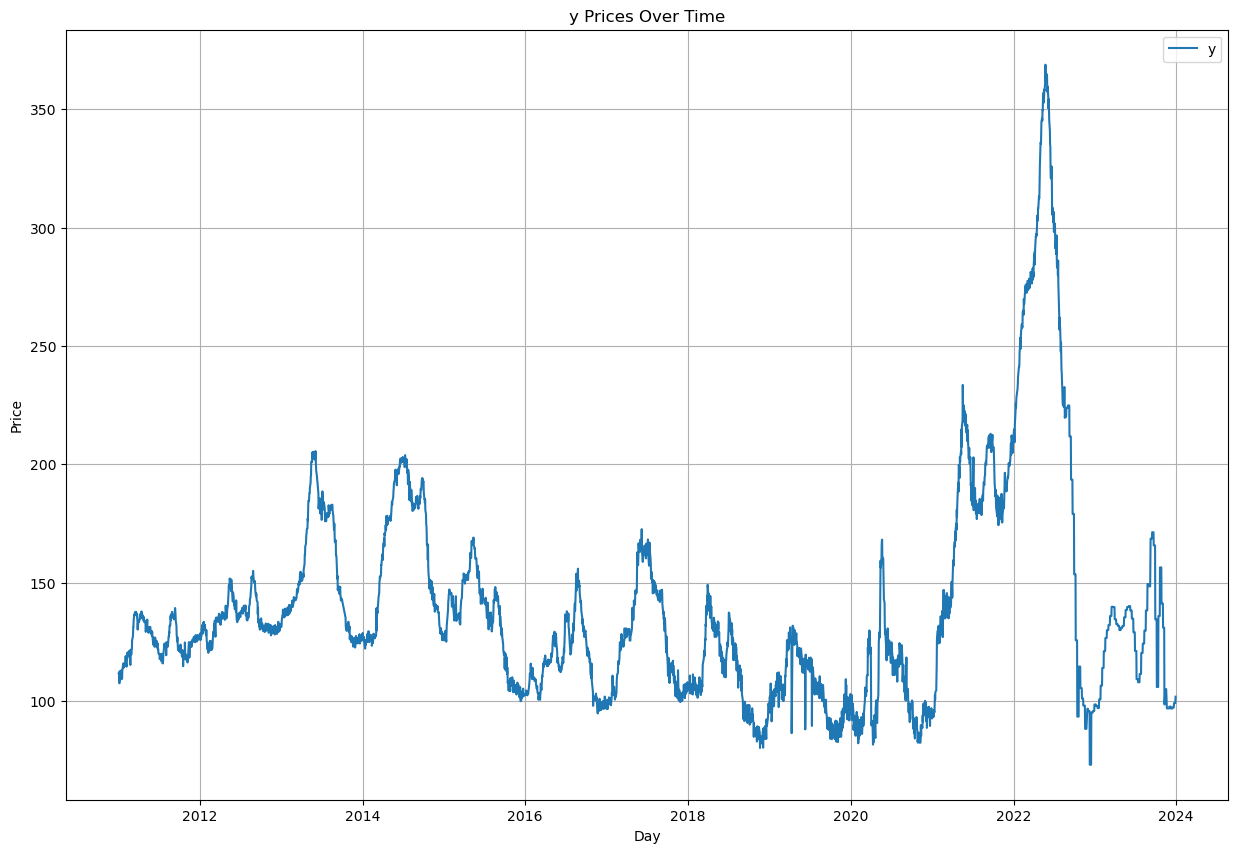

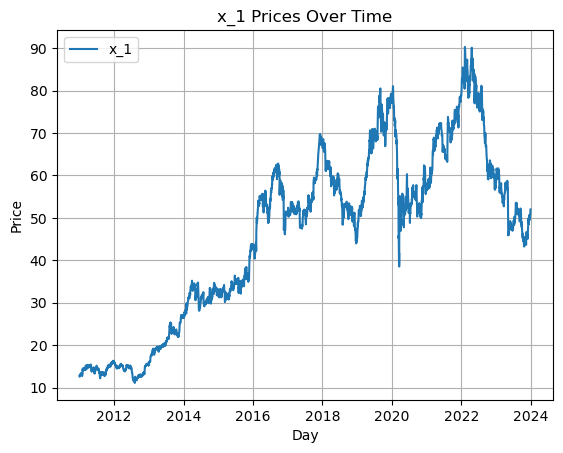

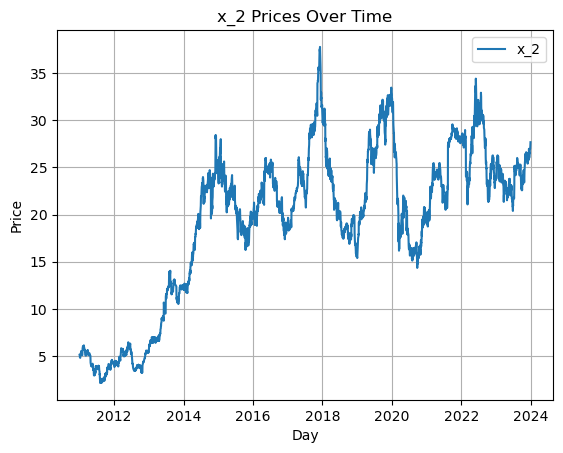

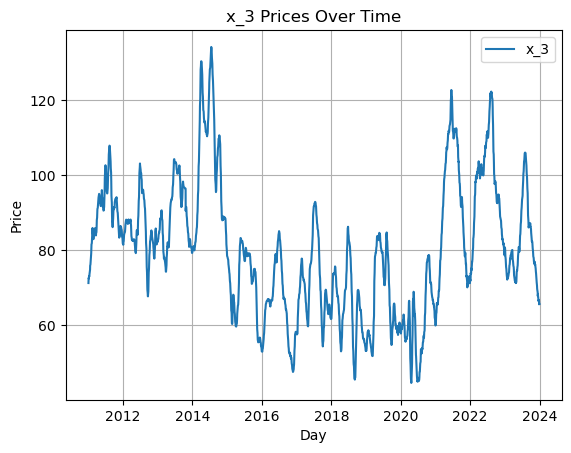

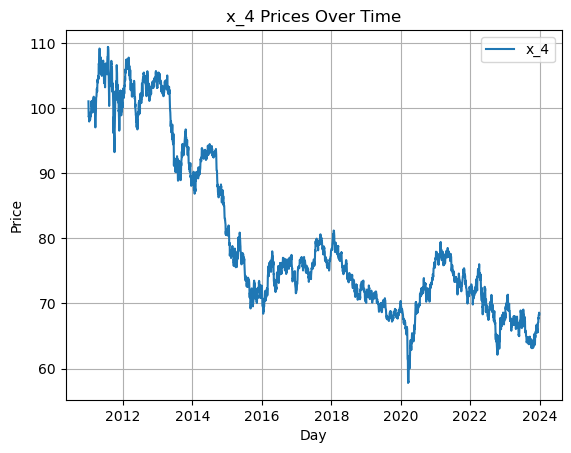

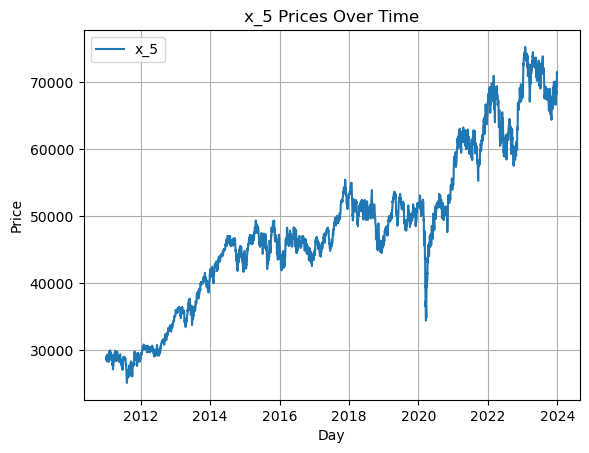

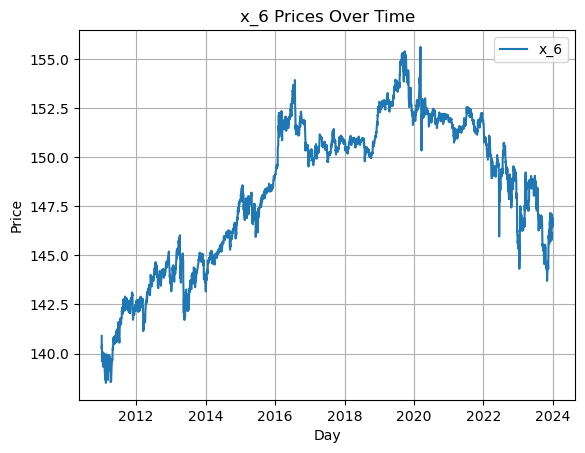

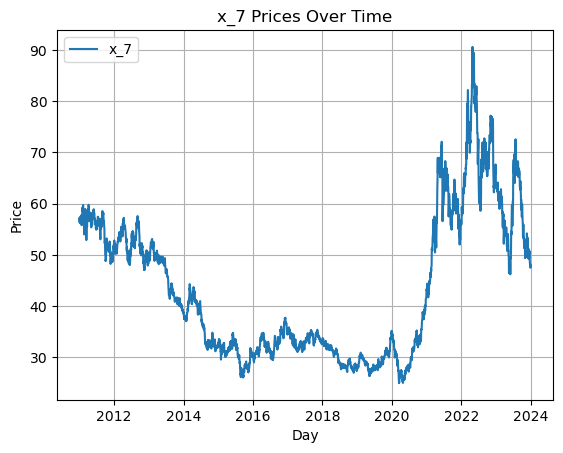

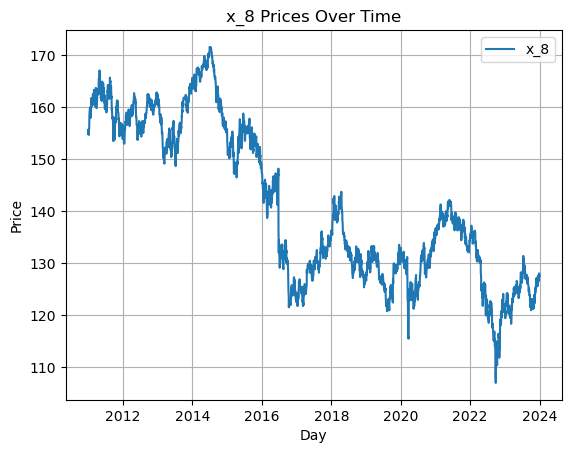

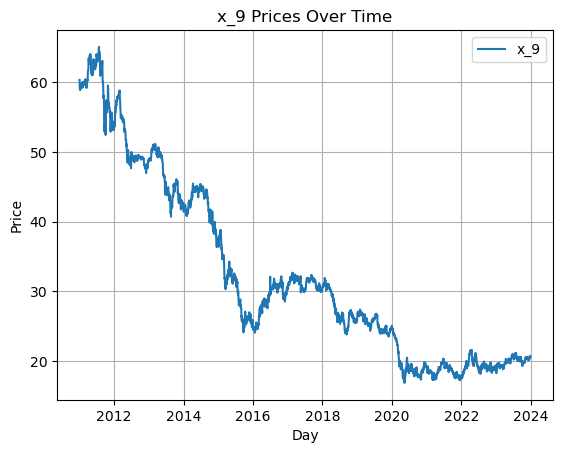

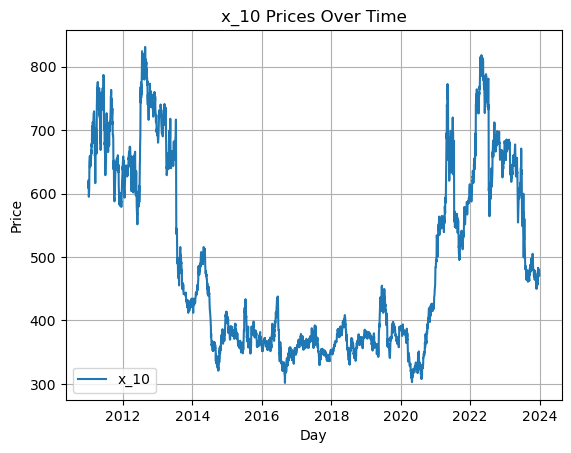

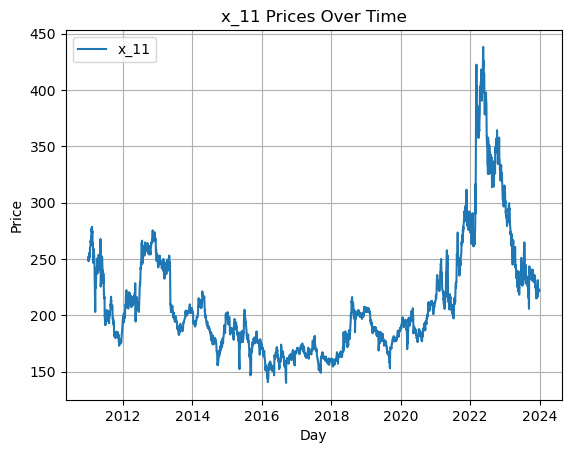

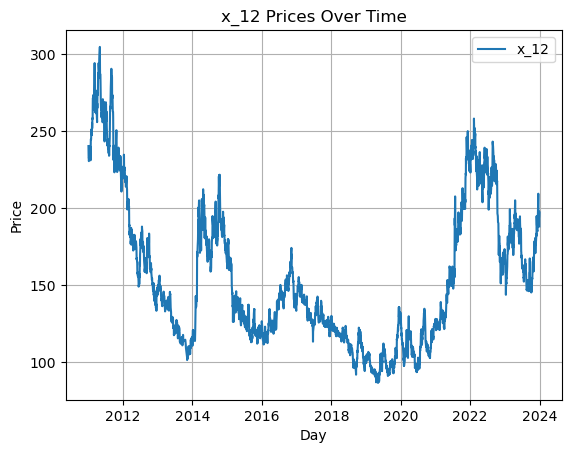

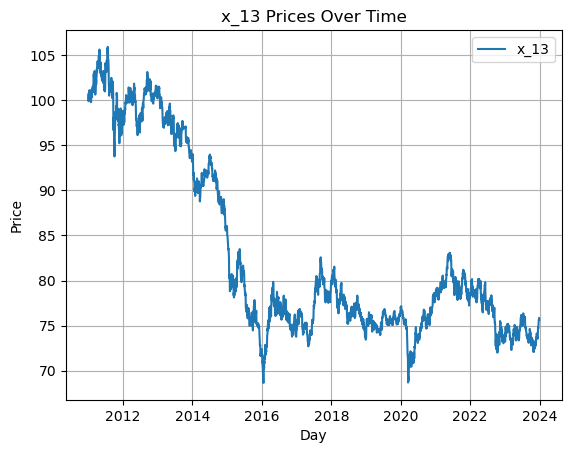

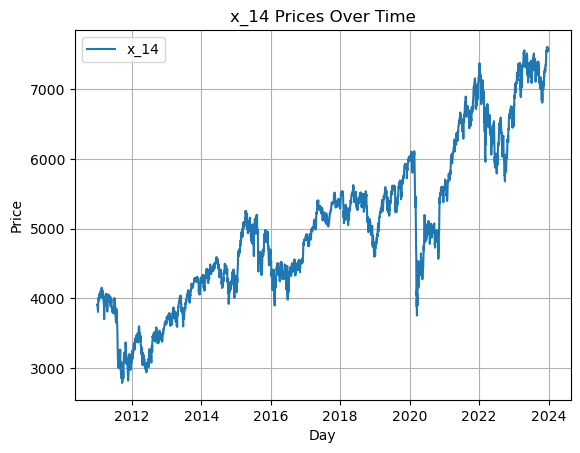

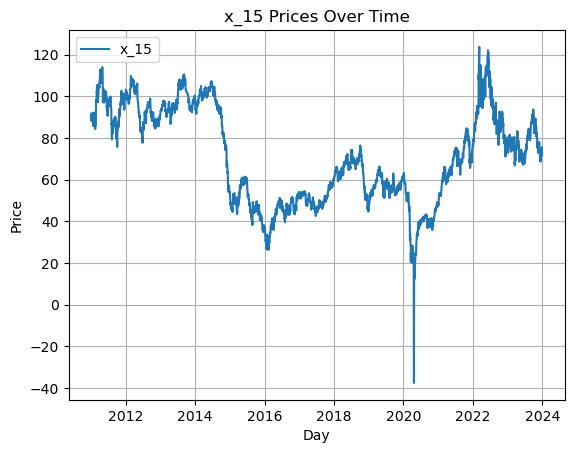

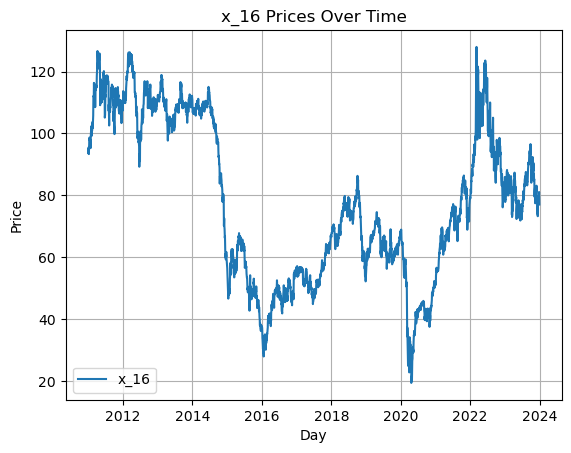

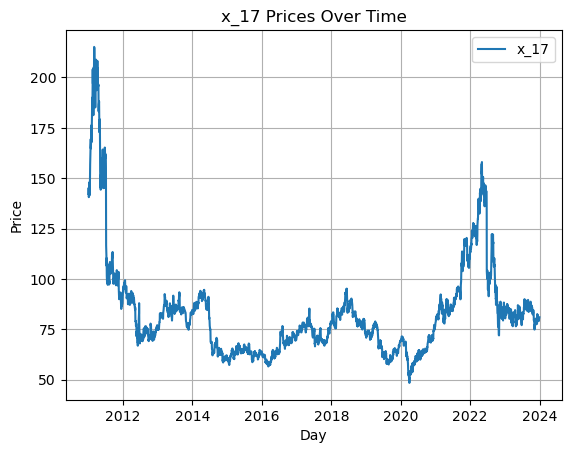

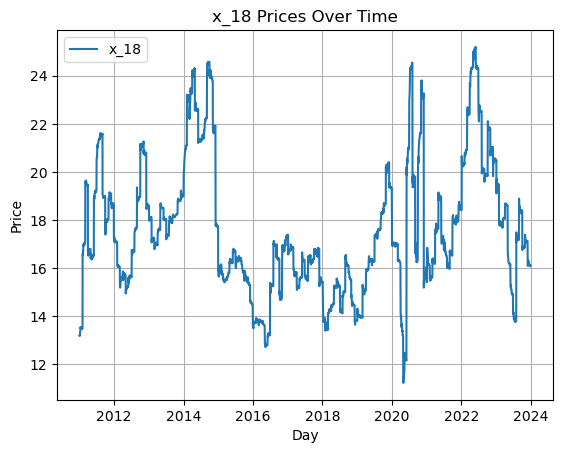

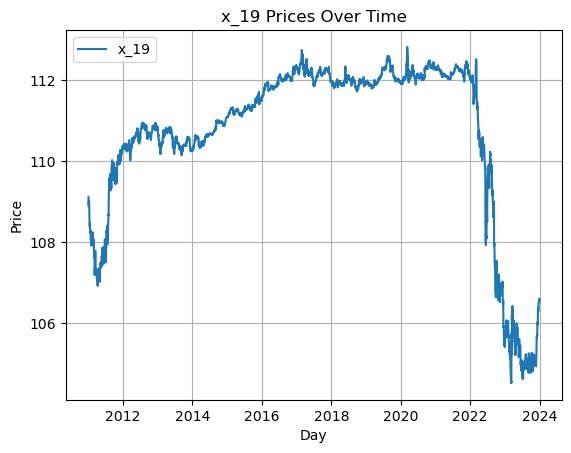

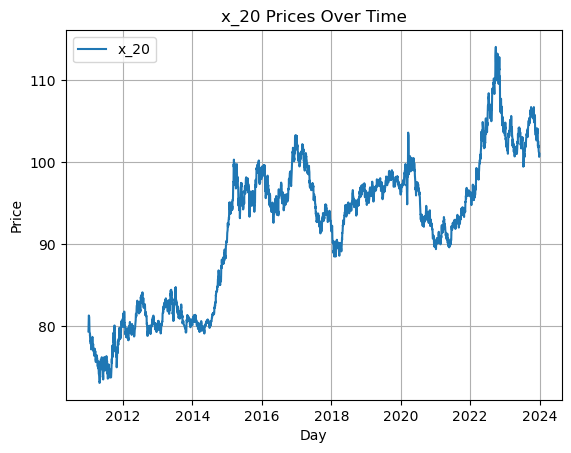

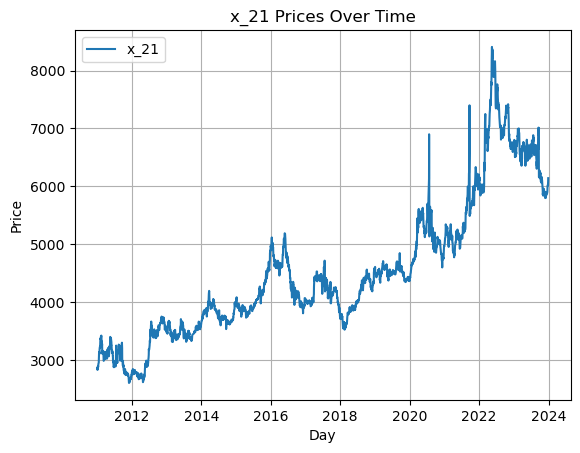

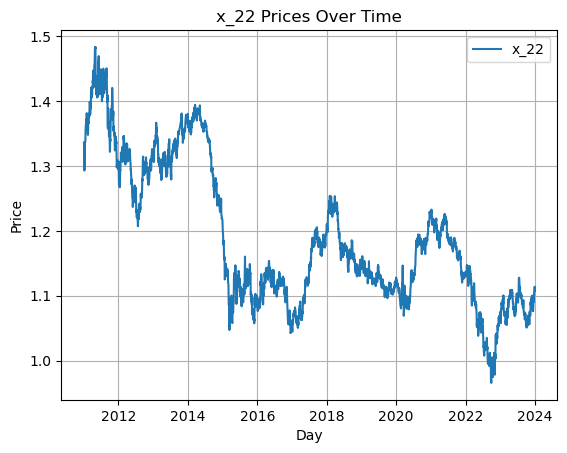

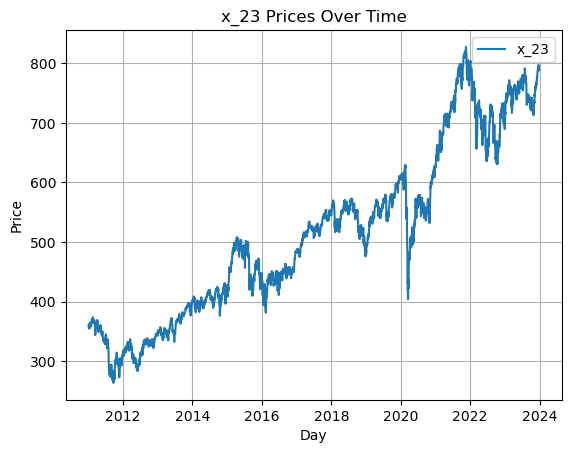

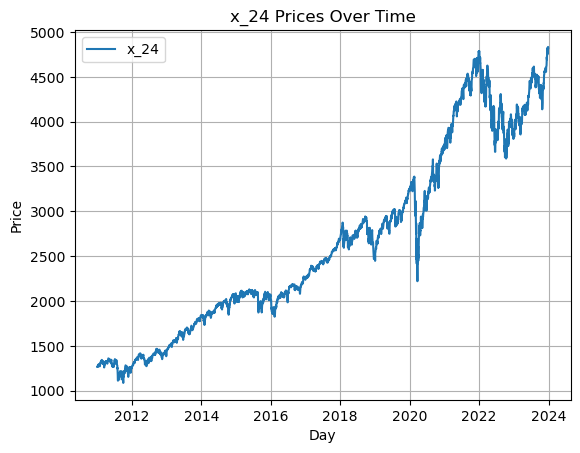

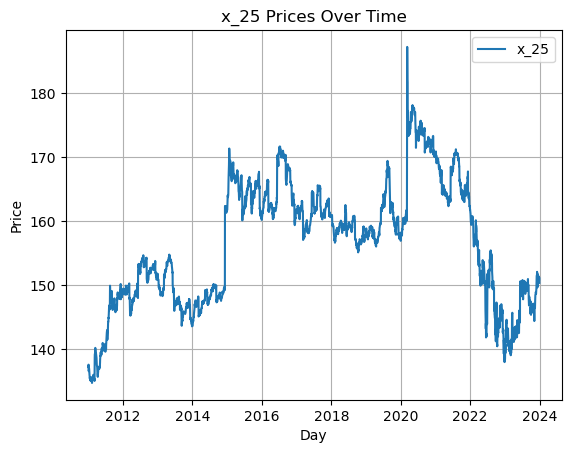

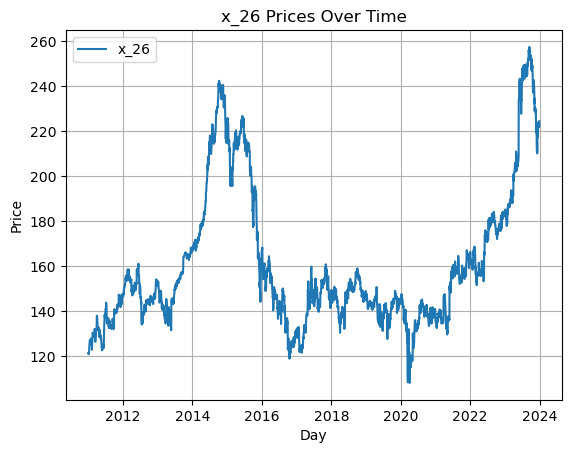

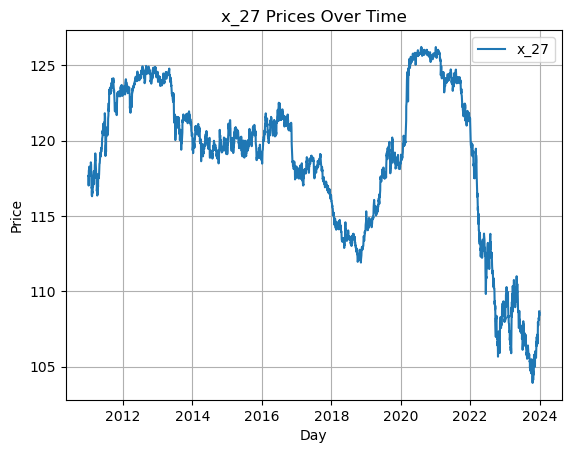

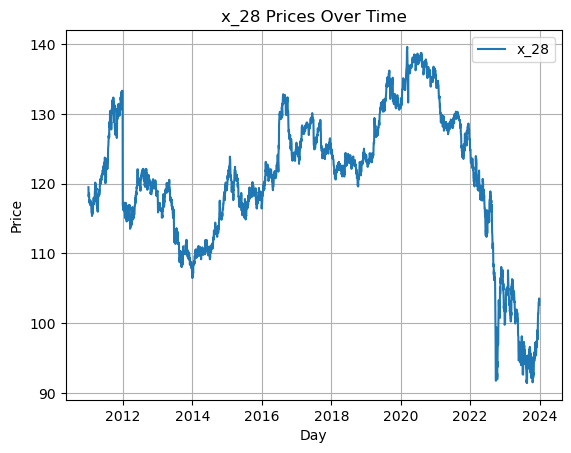

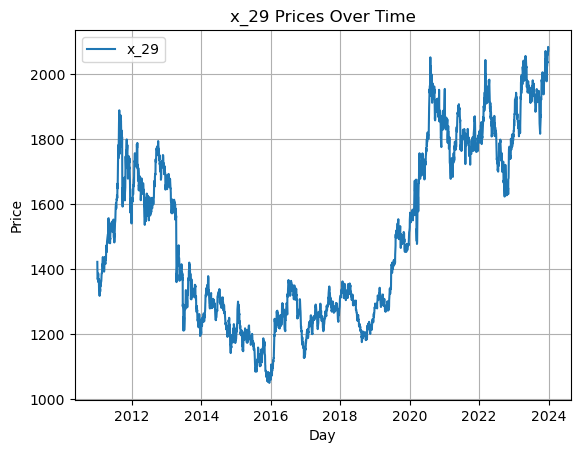

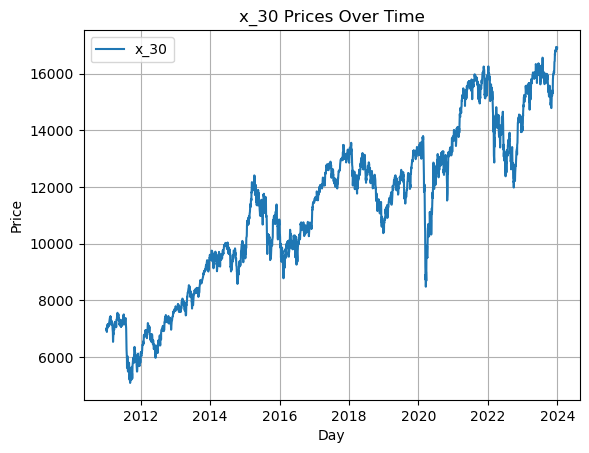

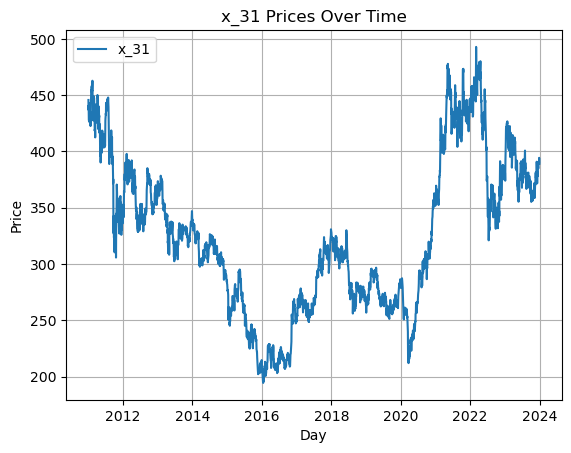

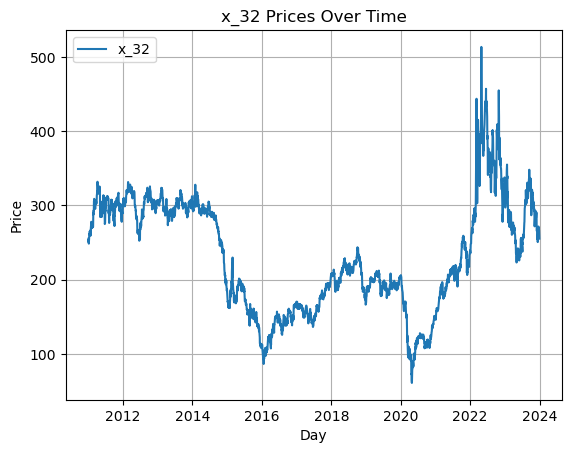

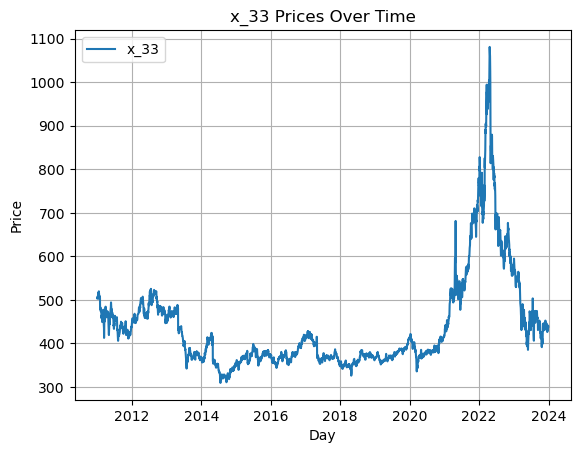

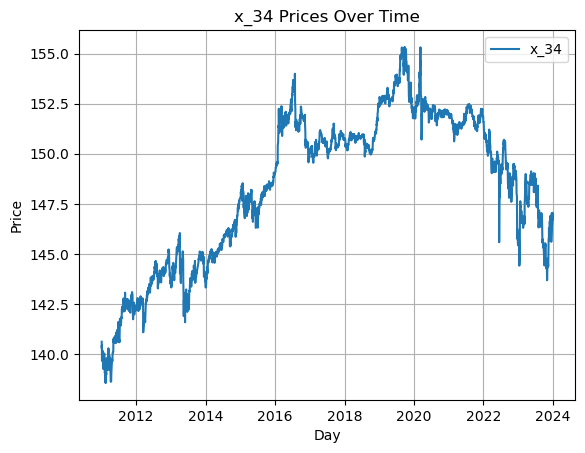

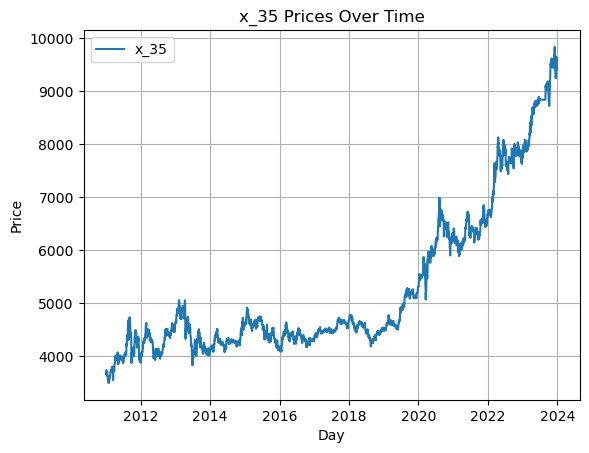

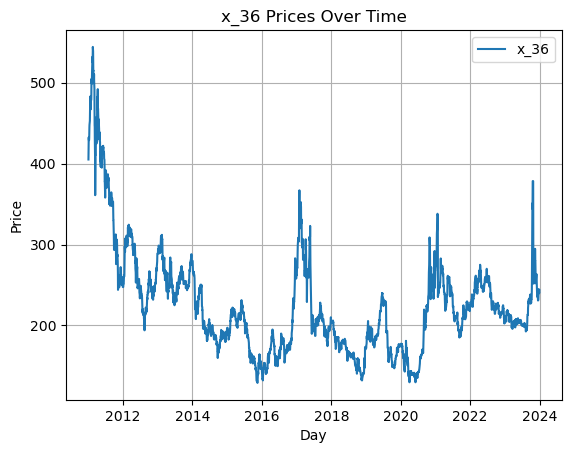

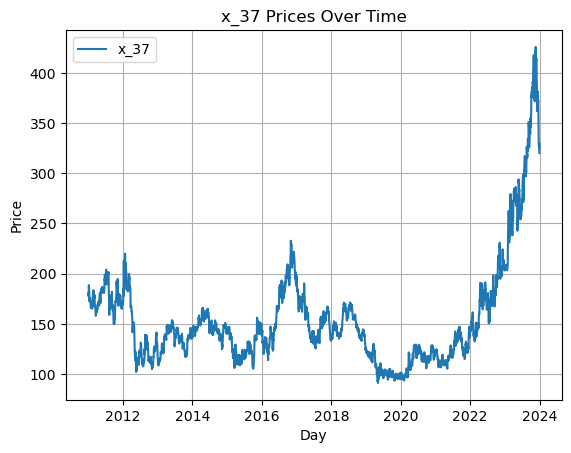

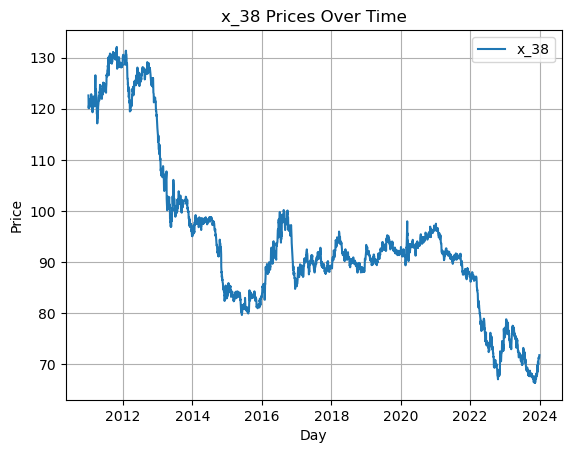

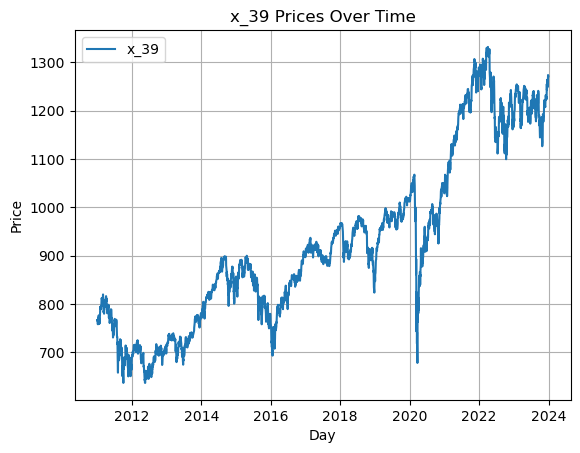

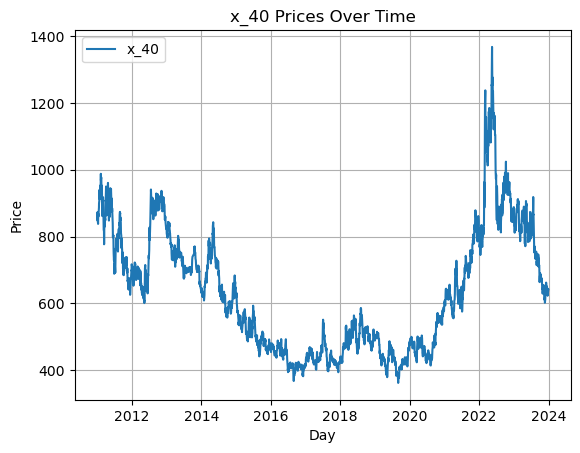

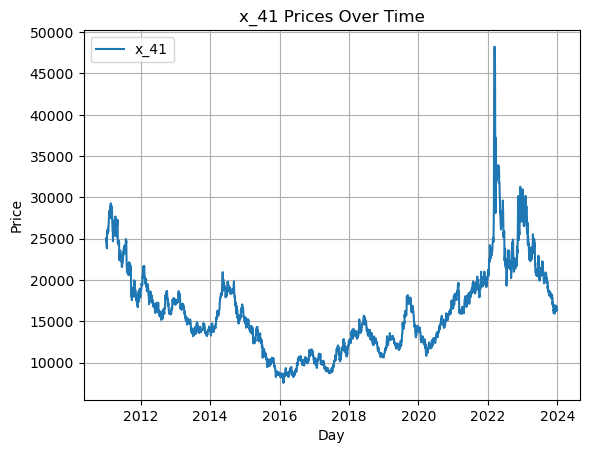

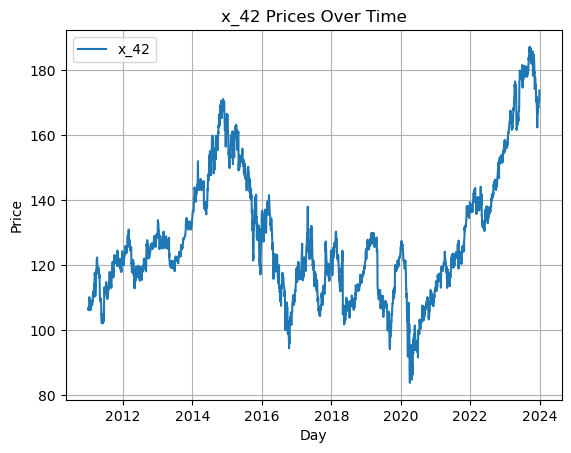

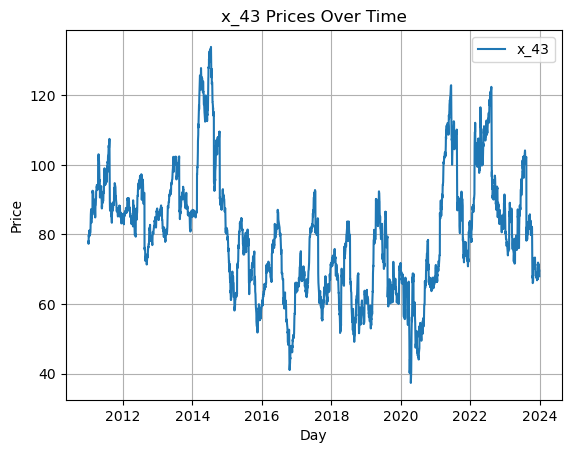

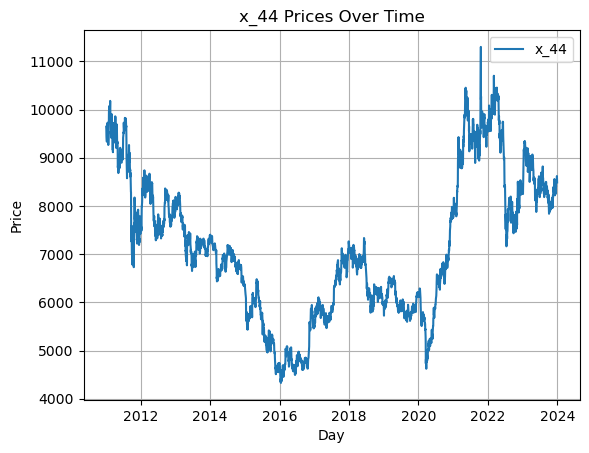

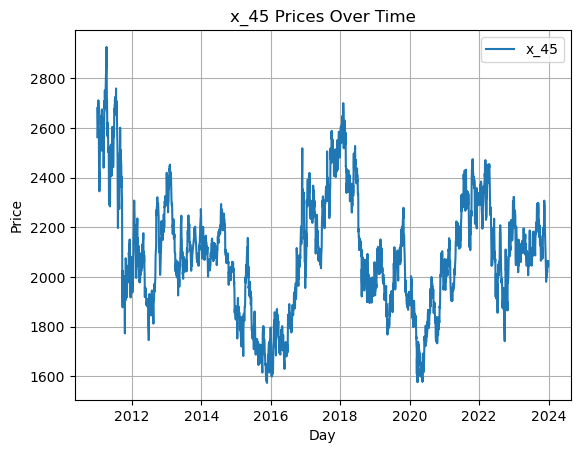

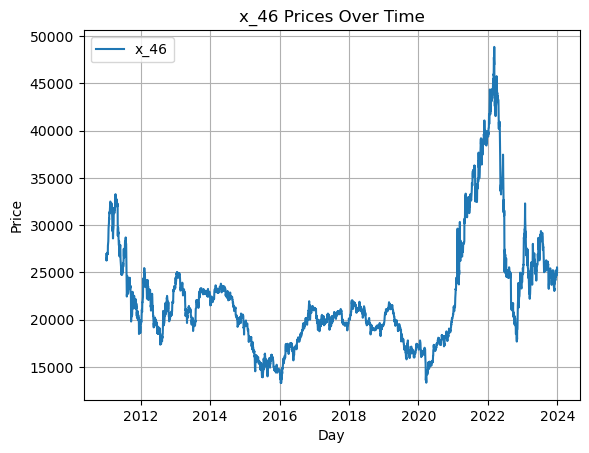

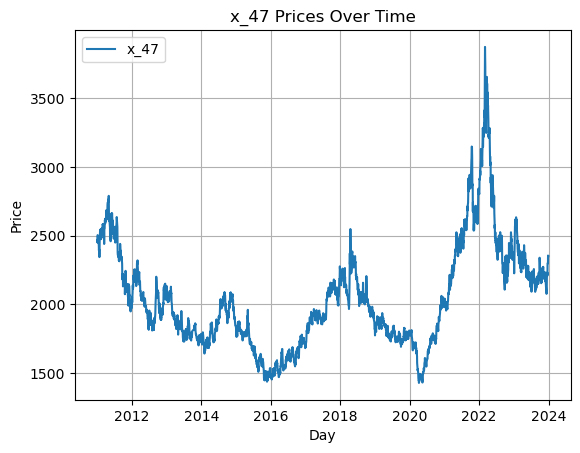

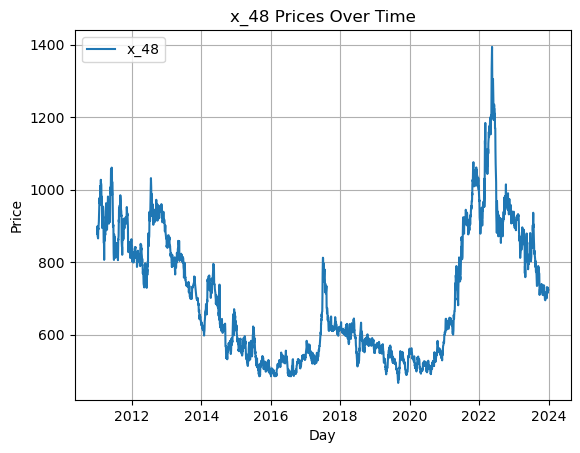

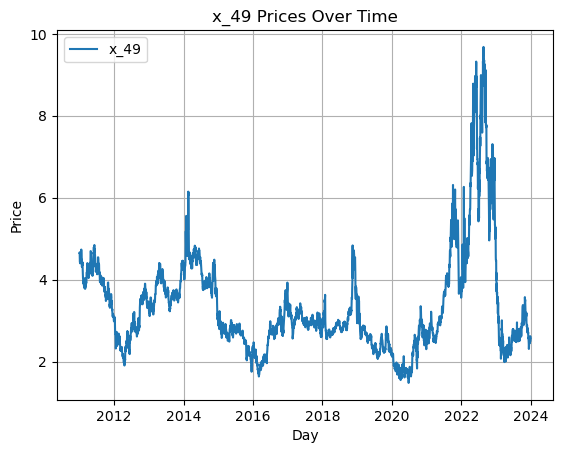

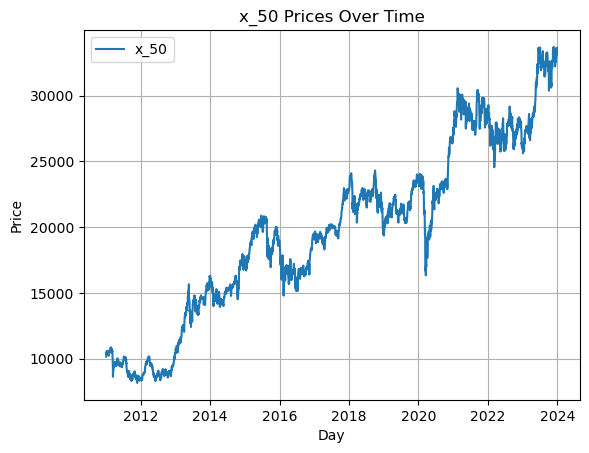

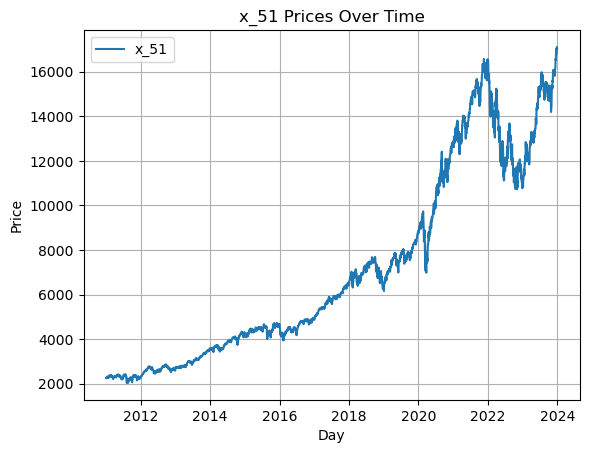

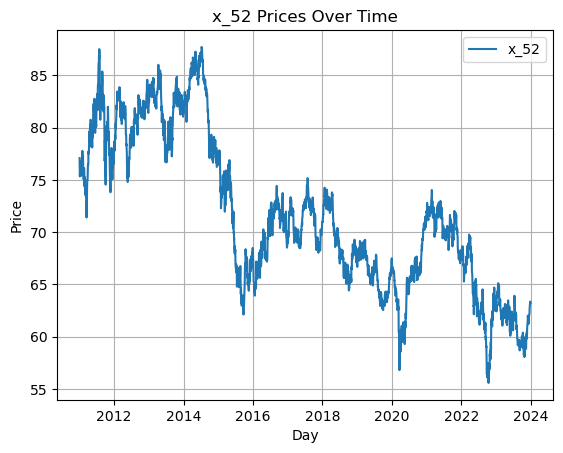

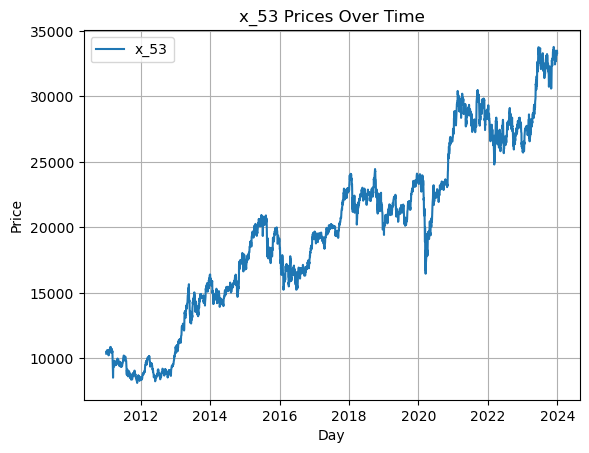

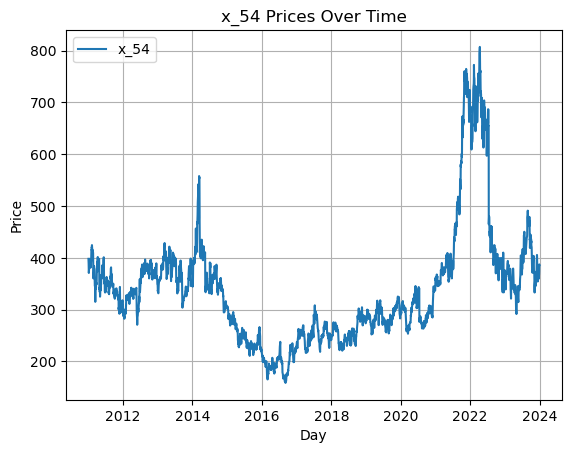

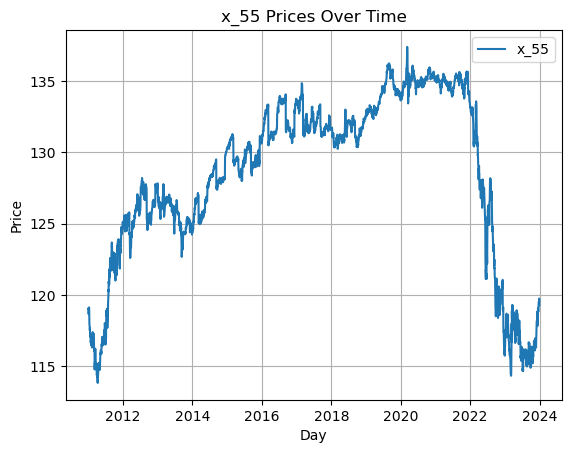

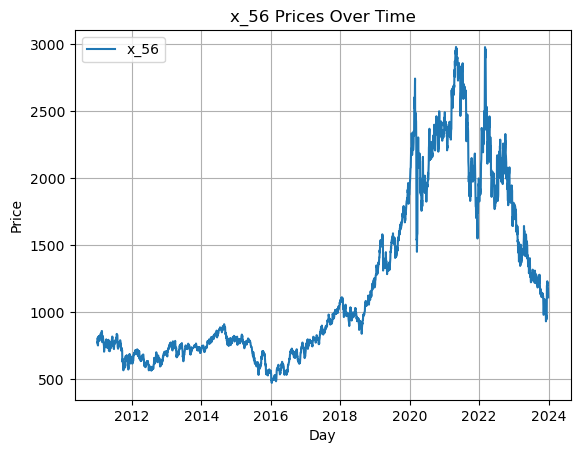

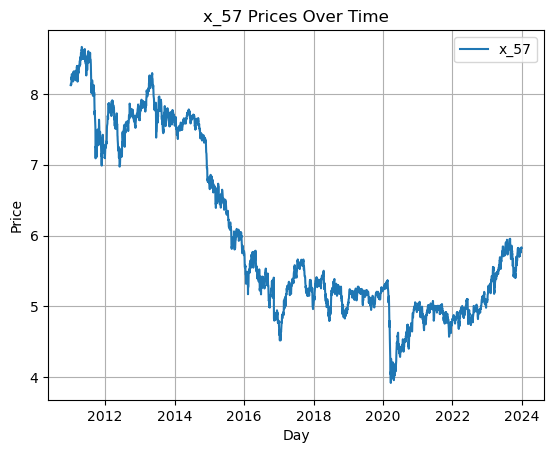

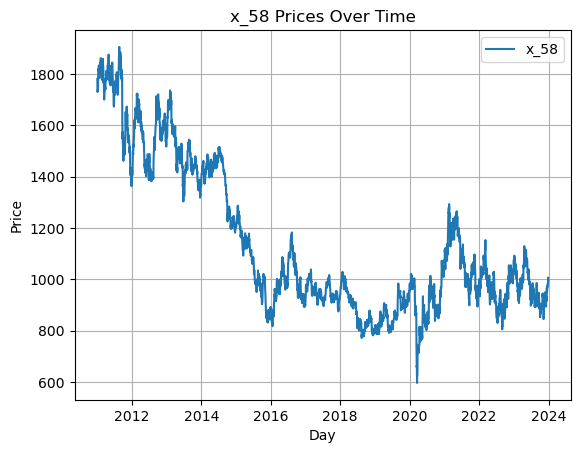

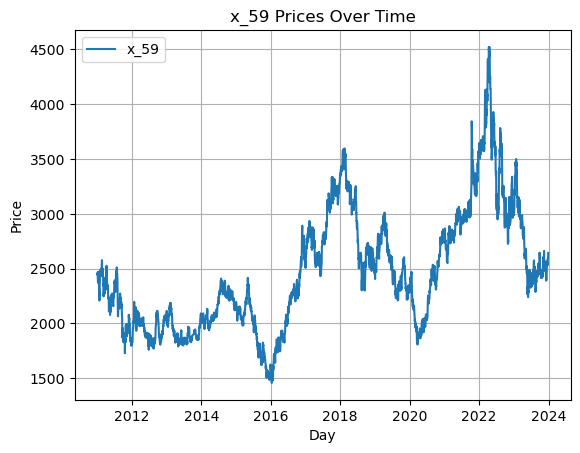

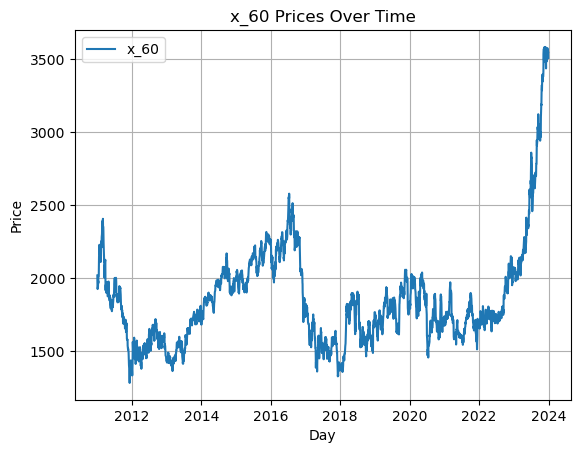

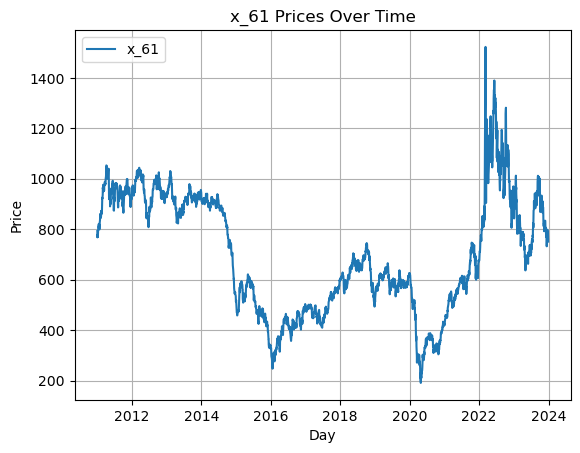

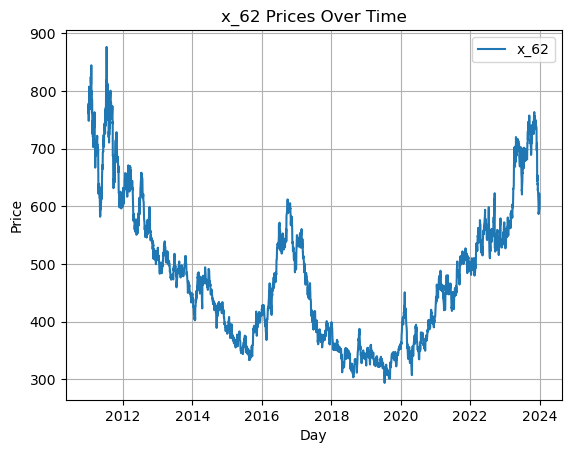

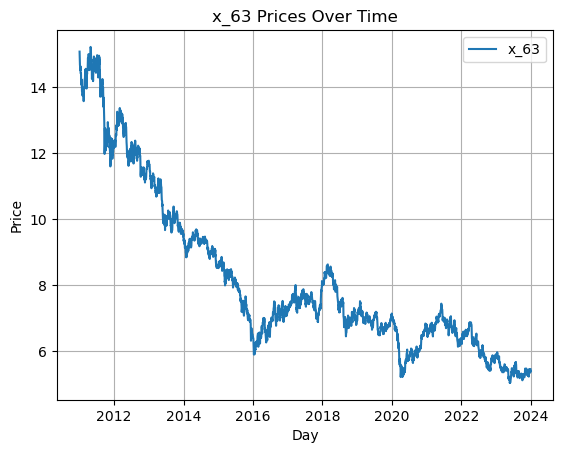

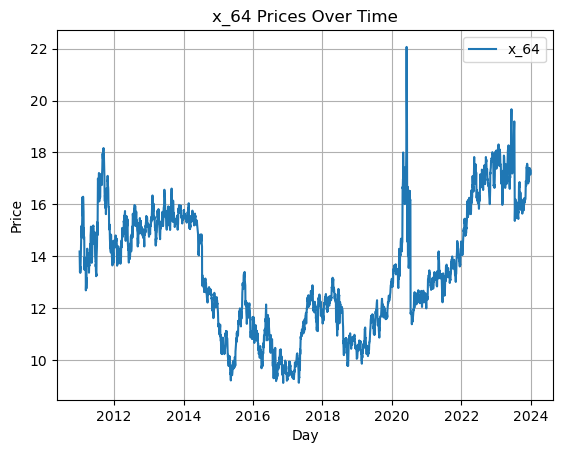

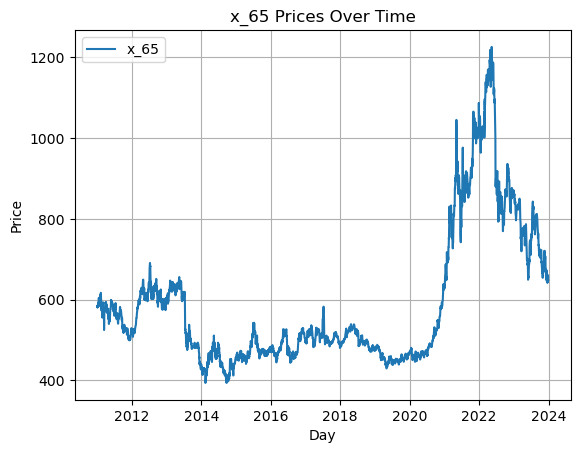

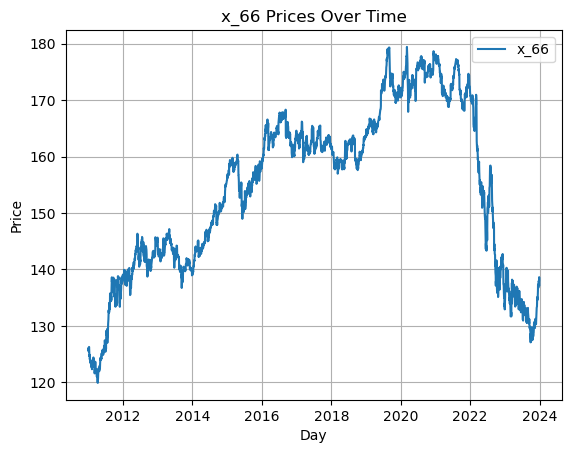

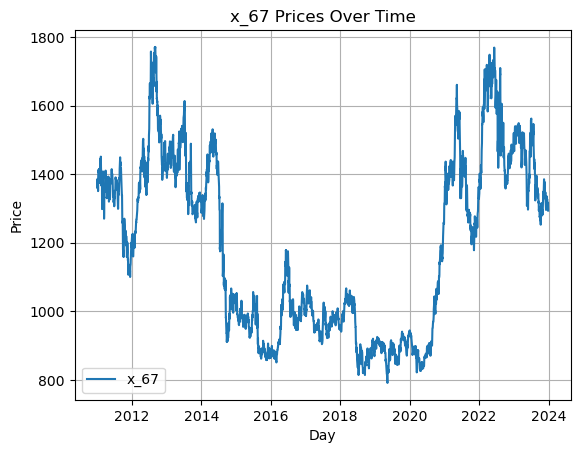

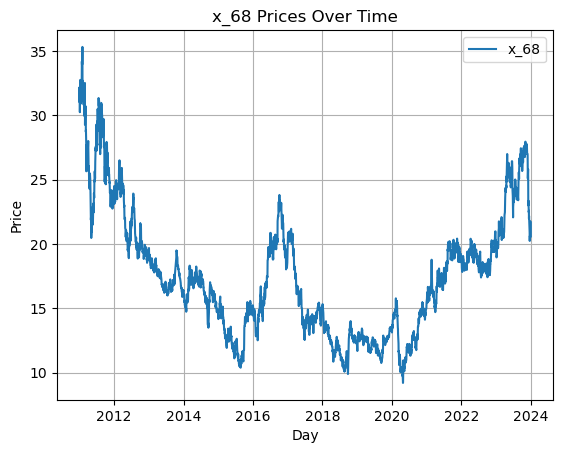

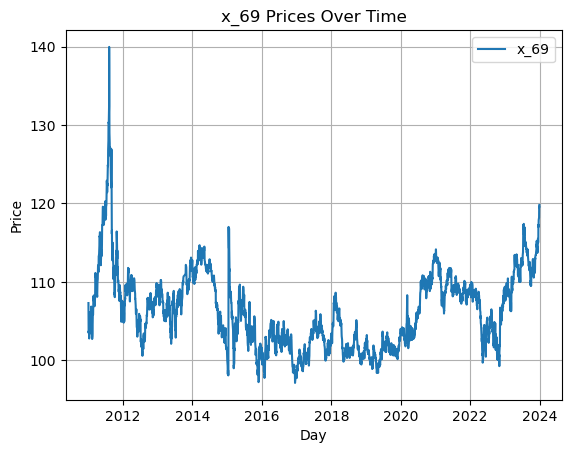

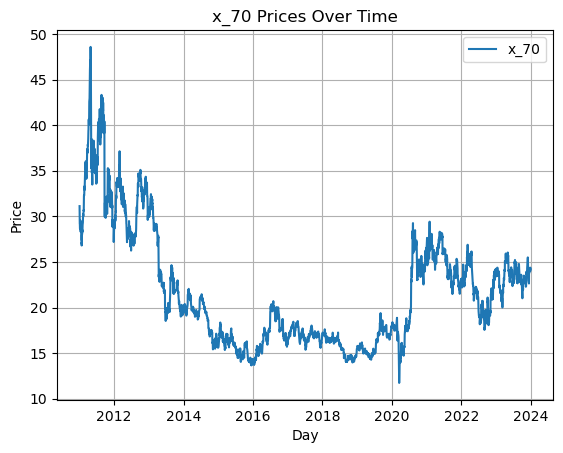

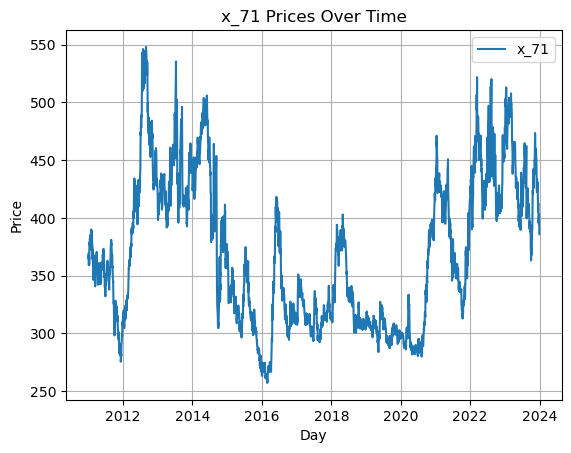

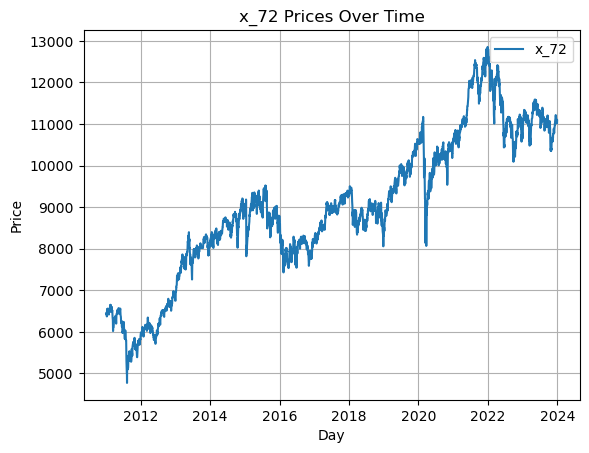

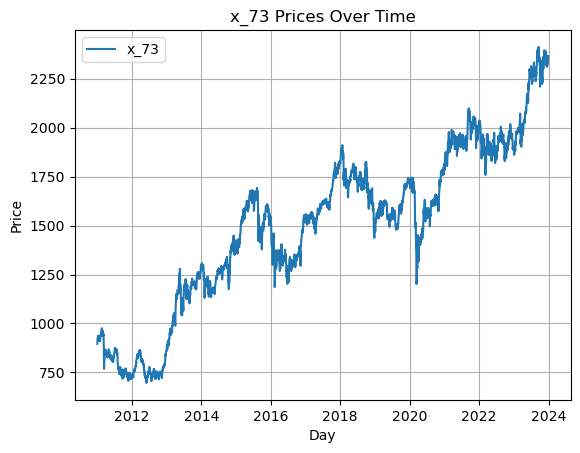

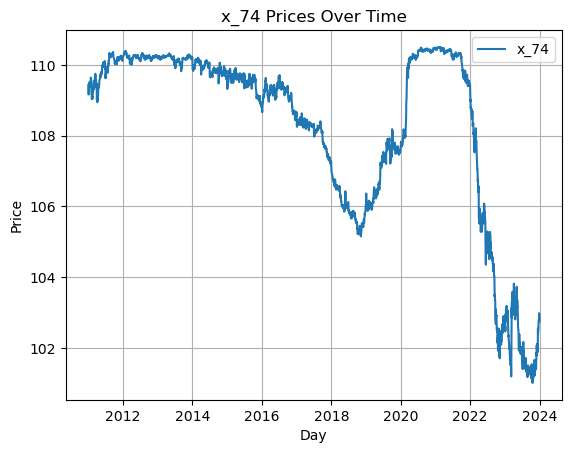

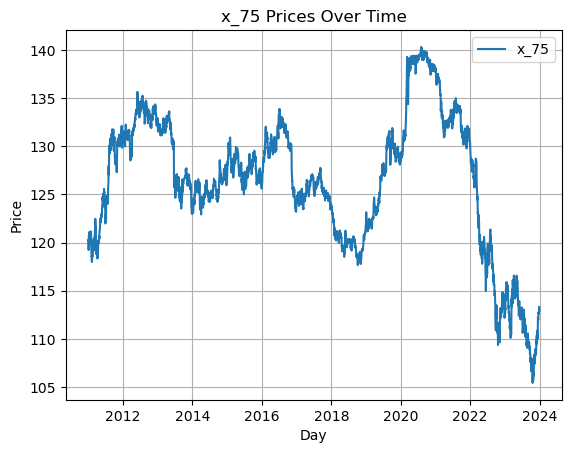

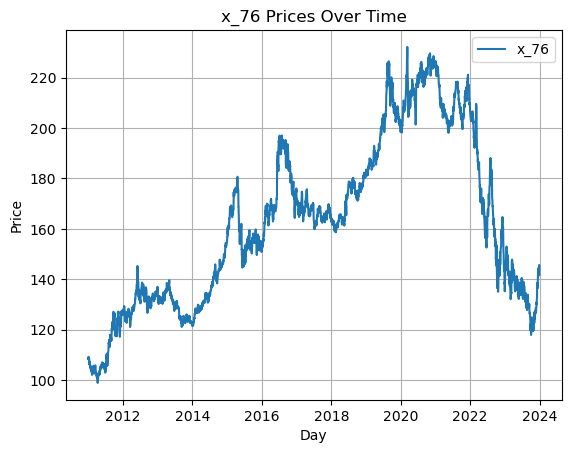

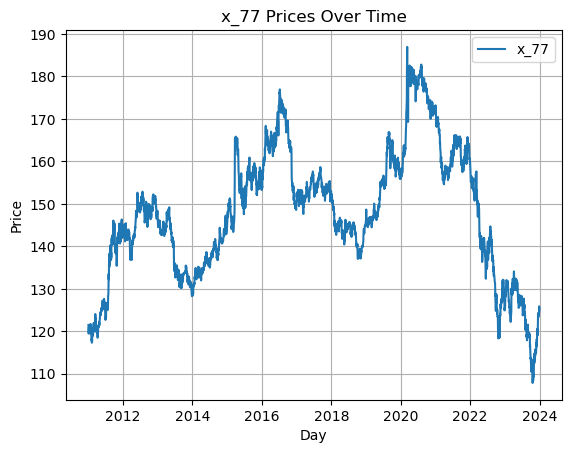

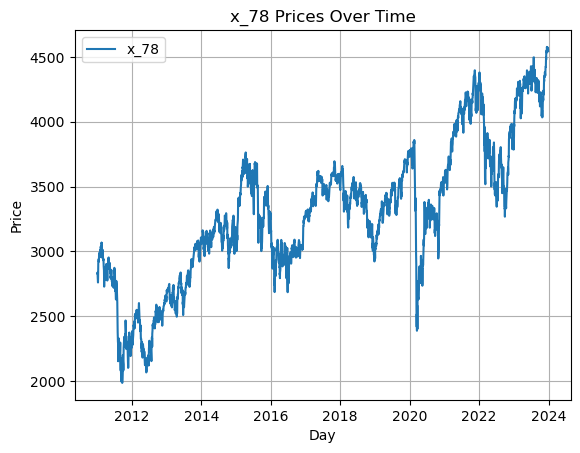

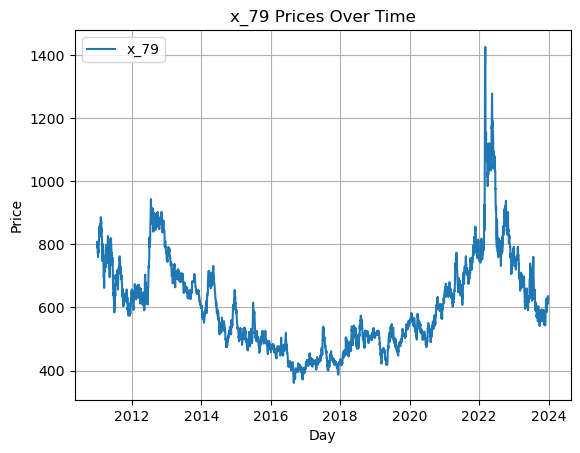

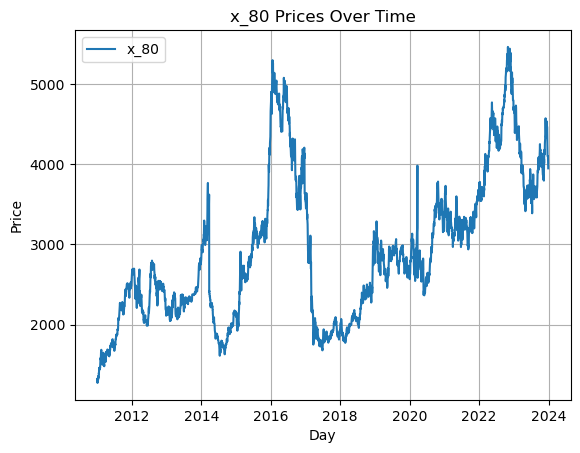

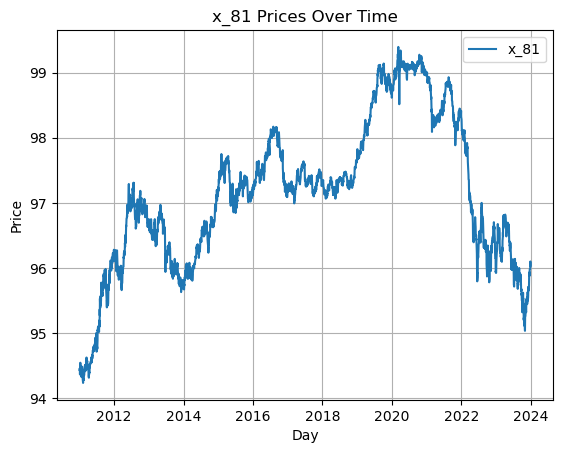

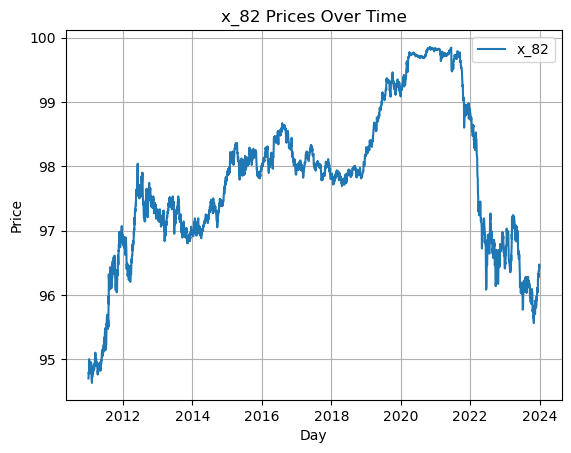

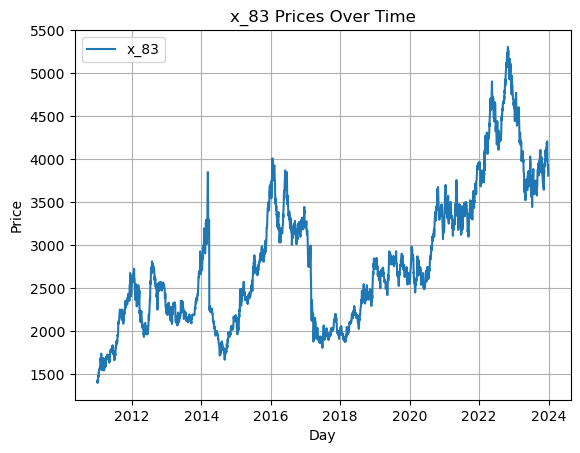

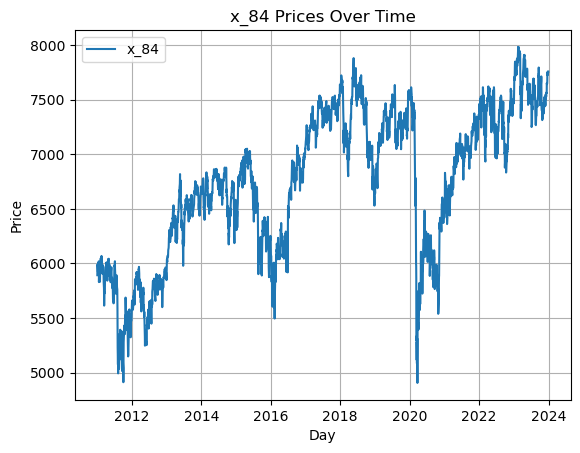

In [16]:
plt.figure(figsize=(15, 10))
for price in data.columns:

    plt.plot(data.index, data[price].values, label=price)
    plt.title(price + ' Prices Over Time')
    plt.xlabel('Day')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.show()

# Check for outliers using boxplots

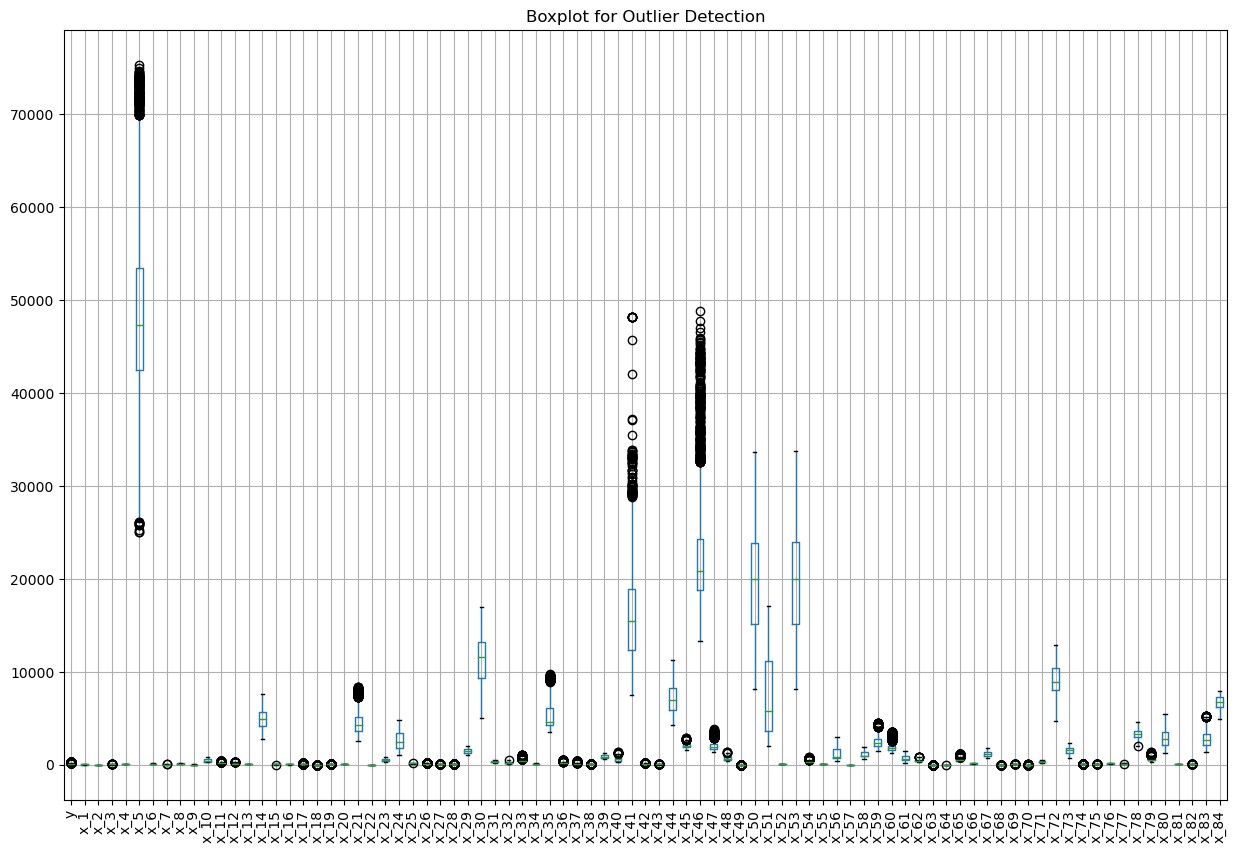

In [17]:
plt.figure(figsize=(15, 10))
data.boxplot(rot=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

# Identify potential outliers using the IQR method

In [18]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
outliers = ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).sum()
print("Potential Outliers per Column:")
print(outliers[outliers > 0])

Potential Outliers per Column:
y       207
x_3      24
x_5     164
x_7       2
x_11    184
x_12     33
x_15      1
x_17    270
x_18    121
x_19    415
x_21     89
x_25      1
x_26    225
x_27     91
x_28    153
x_32      1
x_33    261
x_35     78
x_36    160
x_37    218
x_38    635
x_40     13
x_41     76
x_42    112
x_43     42
x_45     19
x_46    262
x_47     98
x_48      5
x_49    175
x_54    210
x_59     32
x_60    124
x_62      6
x_63    177
x_64      1
x_65    270
x_68     70
x_69     40
x_70     80
x_74    226
x_75     41
x_77      1
x_78      1
x_79     77
x_82     48
x_83     15
dtype: int64


# Define Outlier Limits to remove outliers in y

In [19]:
Q1 = data["y"].quantile(0.25)
Q3 = data["y"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
data = data[(data["y"] >= lower_bound) & (data["y"] <= upper_bound)]

# Correlation matrix to assess relationships between y and other variables

In [20]:
correlation_matrix = data.corr()

# Correlation of y with other variables

In [21]:
y_correlation = correlation_matrix["y"].sort_values(ascending=False)
print("Correlation of 'y' with other variables:")
y_correlation

Correlation of 'y' with other variables:


y       1.000000
x_3     0.660476
x_43    0.624329
x_54    0.482578
x_46    0.432134
          ...   
x_1    -0.220443
x_80   -0.241899
x_6    -0.280109
x_34   -0.280132
x_20   -0.314062
Name: y, Length: 85, dtype: float64

# Visualizing the correlation heatmap

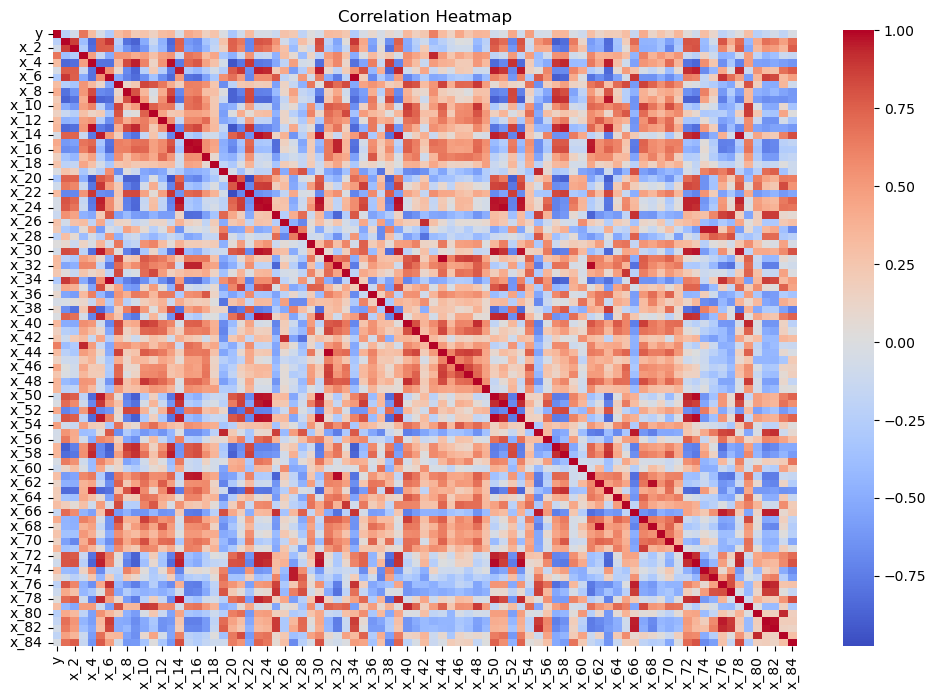

In [22]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", annot=False, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Splitting the dataset into features (X) and target (y)

In [23]:
X = data.drop(columns=["y"])
y = data["y"]

# Standardize the features

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train / Test / Validation:

Next, we can move on to splitting the dataset into training, validation, and test sets.
The dataset contains 3314 data points, which is approximately 13 years of trading data (assuming 250 trading days per year).

Given this:

- We'll use roughly 2455 days for training which is 80% of the dataset
- The remaining data will be used for validation.

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 42)

In [26]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(2455, 84)
(2455,)
(614, 84)
(614,)


#  Linear regression model to predict 'y'

In [27]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [28]:
y_pred = lr_model.predict(X_test)
model_score = lr_model.score(X_test, y_test)
print(f"R^2 Score of the Linear Regression Model: {model_score:.2f}")

R^2 Score of the Linear Regression Model: 0.87


We obtain a very good value for R-squared nearly 90% of the variance in y is explained by the x_i

# Plotting actual vs. predicted values

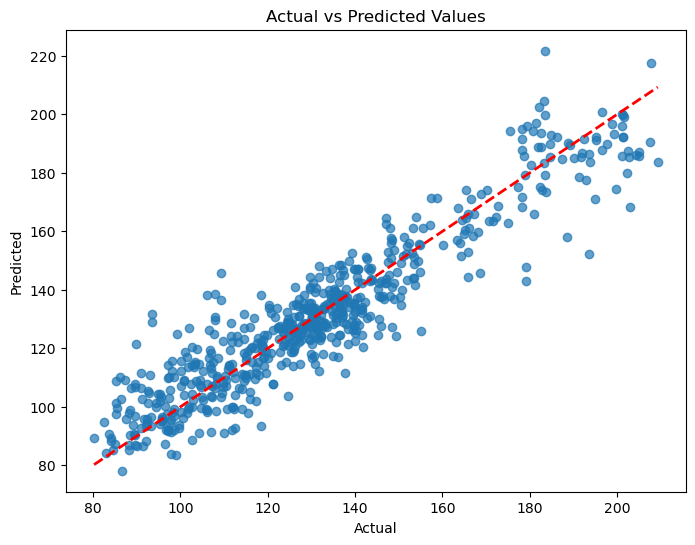

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Values")
plt.show()


# Static Hedging

Static hedge ratios are derived from the coefficients of the linear regression model

In [30]:
hedge_ratios = lr_model.coef_
print("Static Hedge Ratios:")
for idx, ratio in enumerate(hedge_ratios):
    print(f"x_{idx + 1}: {ratio:.4f}")

Static Hedge Ratios:
x_1: 3.0521
x_2: 2.9611
x_3: 4.8663
x_4: -8.0594
x_5: -11.3057
x_6: -14.1317
x_7: -0.6517
x_8: 7.0007
x_9: -9.3613
x_10: 11.4825
x_11: -4.6780
x_12: 2.9164
x_13: 2.0590
x_14: -4.9585
x_15: 18.1708
x_16: 3.2864
x_17: 4.6250
x_18: 1.5169
x_19: -6.9216
x_20: 29.7384
x_21: 19.0453
x_22: 0.2821
x_23: 0.7034
x_24: -89.6963
x_25: 3.2300
x_26: 4.7473
x_27: -9.9781
x_28: 2.1114
x_29: -3.3291
x_30: 4.8933
x_31: 3.9288
x_32: -2.7023
x_33: -6.9490
x_34: 3.8548
x_35: 20.1054
x_36: -3.8798
x_37: -2.3596
x_38: 22.4727
x_39: -7.7559
x_40: 7.3992
x_41: -4.9370
x_42: -1.3571
x_43: 0.7510
x_44: -6.2676
x_45: -5.7065
x_46: 10.2810
x_47: 0.6840
x_48: -1.3571
x_49: 0.6736
x_50: -26.7393
x_51: 84.3834
x_52: 9.0847
x_53: -1.6744
x_54: -3.2376
x_55: 7.7069
x_56: 1.6521
x_57: 26.6731
x_58: 5.7999
x_59: 8.6583
x_60: 4.1649
x_61: -6.2884
x_62: -1.3596
x_63: -4.2317
x_64: -0.2284
x_65: 22.0776
x_66: 3.4887
x_67: 3.8714
x_68: -6.1206
x_69: 1.8188
x_70: -10.9125
x_71: -5.0665
x_72: 7.1395
x_73: 

# Dynamic Hedging

In dynamic hedging, hedge ratios are updated over time using rolling-window regressions

In [31]:
rolling_window = 50  # Define the rolling window size for dynamic hedging
dynamic_hedge_ratios = []
dynamic_predictions = []
for i in range(rolling_window, len(X_scaled)):
    X_window = X_scaled[i-rolling_window:i]  # Extract a rolling window of features
    y_window = y[i-rolling_window:i]         # Extract a rolling window of the target
    lr_dynamic = LinearRegression()         # Create a new regression model for each window
    lr_dynamic.fit(X_window, y_window)      # Fit the model to the rolling window data
    dynamic_hedge_ratios.append(lr_dynamic.coef_)
    dynamic_predictions.append(np.dot(X_scaled[i], lr_dynamic.coef_))
dynamic_hedge_ratios = np.array(dynamic_hedge_ratios)

dynamic_hedge_ratios

array([[ -1.25296321,   9.60146648,   5.26524062, ..., -12.40275488,
         26.0343223 ,   2.36877323],
       [  5.82723972,   3.74666054,   6.20517033, ..., -16.33078063,
         12.47353445,   1.62760634],
       [  6.06410262,   6.72724312,   2.49248459, ..., -10.43460416,
         12.31131888,   1.22882829],
       ...,
       [ 40.39154799,   2.48792927, -25.552879  , ...,  -6.18052404,
         19.59312518,  18.0078629 ],
       [ 39.00037574,  -4.59910122, -21.5621699 , ..., -14.9032918 ,
         10.66742514,  17.52522739],
       [ 41.19575942,  -3.12635629, -28.99701904, ..., -24.38713705,
         20.02264064,  15.43428328]])

# Plot dynamic hedge ratios for the first 5 predictors

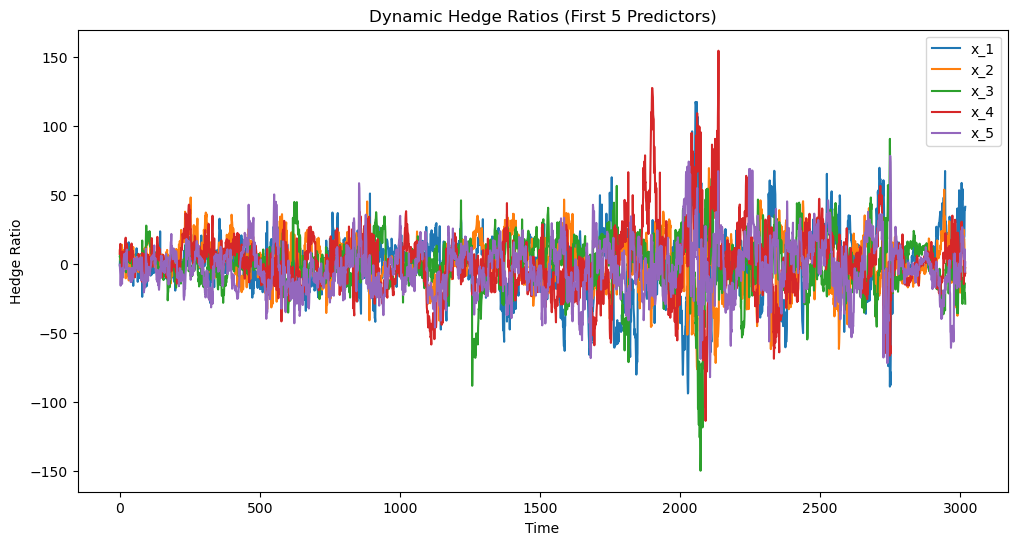

In [32]:
plt.figure(figsize=(12, 6))
for i in range(5):
    plt.plot(dynamic_hedge_ratios[:, i], label=f"x_{i+1}")
plt.title("Dynamic Hedge Ratios (First 5 Predictors)")
plt.xlabel("Time")
plt.ylabel("Hedge Ratio")
plt.legend()
plt.show()



# Compute and plot the spread (y - predicted y)

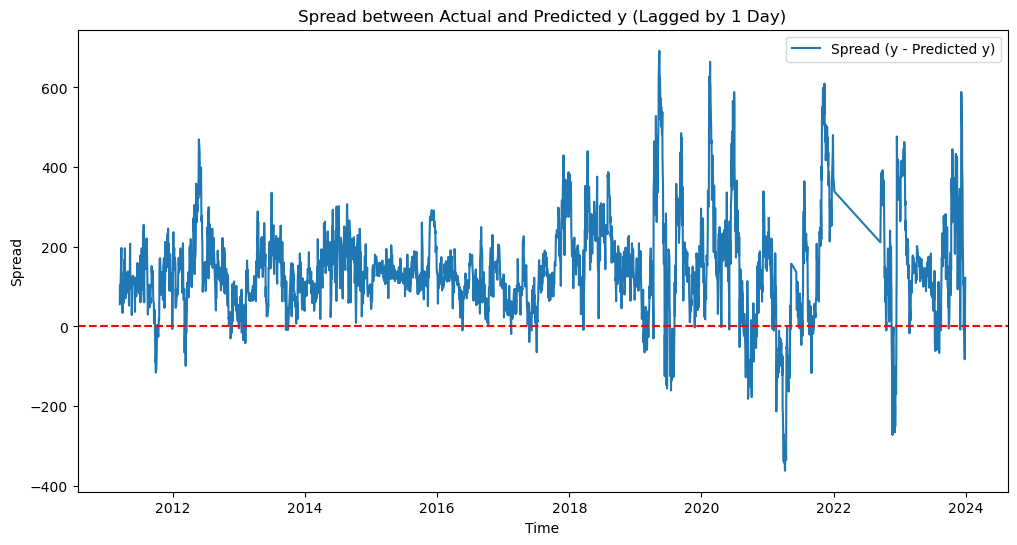

In [33]:
spread = y[rolling_window:] - dynamic_predictions
plt.figure(figsize=(12, 6))
plt.plot(spread, label="Spread (y - Predicted y)")
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Spread between Actual and Predicted y (Lagged by 1 Day)")
plt.xlabel("Time")
plt.ylabel("Spread")
plt.legend()
plt.show()


The negative values between 2020-2022 can be explained by the fact that it was the Covid crisis and that the market suffered a lot 